# ML Overheating Predictor — Offline Training

**Purpose:** Train and evaluate a supervised ML classifier that predicts whether indoor temperature
will exceed 23.1 °C within the next 8 hours. The trained model is intended as a drop-in
replacement (or parallel check) for the physics-based `OverheatingPredictor` in the HA add-on.

**Data sources:**
- `.data/sensordaten_2025-06-19_ab.csv` — heat pump sensor data (AT, RT_*, Pth_H, Pth_PC, VLT, RLT, ...)
- `.data/PV-Daten_2025-06-19_ab.csv` — PV generation data (PV_Generate)

**Day filter rules:**
1. Keep only days where `PV_Generate` is available (non-NaN) for the entire day.
2. Keep only days where `Pth_H < 1000 W` for every row of that day.

**Label:** `label_8h = 1` if `max(indoor_temp over next 8 h) > 23.1 °C`

**Models trained:** RandomForest + LightGBM (or GradientBoosting as fallback)

**Output artifacts** (saved to `models/` next to this notebook):
- `overheating_predictor_rf.joblib`
- `overheating_predictor_lgbm.joblib`
- `model_metadata.json`

## 0. Configuration

In [1]:
import os

# ── Paths ────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = os.path.abspath(os.getcwd())
DATA_DIR = os.path.abspath(os.path.join(NOTEBOOK_DIR, "../../.data"))
MODELS_DIR = os.path.join(NOTEBOOK_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

SENSOR_CSV  = os.path.join(DATA_DIR, "sensordaten_2025-06-19_ab.csv")
PV_CSV      = os.path.join(DATA_DIR, "PV-Daten_2025-06-19_ab.csv")

# ── Label & horizon ──────────────────────────────────────────────────────────
OVERHEAT_THRESHOLD_C = 23.1   # °C — fixed overheating threshold
LABEL_HORIZON_H      = 8      # hours ahead for the primary label
STEPS_PER_HOUR       = 12     # 5-min resolution → 12 steps/h
LABEL_HORIZON_STEPS  = LABEL_HORIZON_H * STEPS_PER_HOUR

# Extra horizon variants for comparison plots
EXTRA_HORIZONS_H = [3, 6, 12]

# ── Data quality ─────────────────────────────────────────────────────────────
PTH_H_MAX_W = 1000.0          # max heating power for a day to be included

# ── Train / test split ───────────────────────────────────────────────────────
TRAIN_FRACTION = 0.75

print("Config loaded.")
print(f"  Sensor CSV : {SENSOR_CSV}")
print(f"  PV CSV     : {PV_CSV}")
print(f"  Models dir : {MODELS_DIR}")
print(f"  Threshold  : {OVERHEAT_THRESHOLD_C} °C")
print(f"  Horizon    : {LABEL_HORIZON_H} h ({LABEL_HORIZON_STEPS} steps)")

Config loaded.
  Sensor CSV : c:\Users\Julia\Documents\Johannes\Pi 4\GitHub\ml_heating_underfloor-main\.data\sensordaten_2025-06-19_ab.csv
  PV CSV     : c:\Users\Julia\Documents\Johannes\Pi 4\GitHub\ml_heating_underfloor-main\.data\PV-Daten_2025-06-19_ab.csv
  Models dir : c:\Users\Julia\Documents\Johannes\Pi 4\GitHub\ml_heating_underfloor-main\notebooks\analysis\models
  Threshold  : 23.1 °C
  Horizon    : 8 h (96 steps)


## 1. Imports

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
from datetime import datetime

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

# Try LightGBM, fall back to GradientBoosting
try:
    import lightgbm as lgb
    USE_LGBM = True
    print("LightGBM available ✓")
except ImportError:
    USE_LGBM = False
    print("LightGBM not found — using sklearn GradientBoostingClassifier instead")

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)
print("Imports OK")

LightGBM available ✓
Imports OK


## 2. Data Loading

In [3]:
# ── Load sensor data (chunked to handle large files) ─────────────────────────
print("Loading sensor data…")
sensor_chunks = []
for chunk in pd.read_csv(SENSOR_CSV, chunksize=50_000, low_memory=False):
    sensor_chunks.append(chunk)
sensor_raw = pd.concat(sensor_chunks, ignore_index=True)
print(f"  Sensor rows: {len(sensor_raw):,}   columns: {sensor_raw.shape[1]}")

# ── Load PV data ──────────────────────────────────────────────────────────────
print("Loading PV data…")
pv_chunks = []
for chunk in pd.read_csv(PV_CSV, chunksize=50_000, low_memory=False):
    pv_chunks.append(chunk)
pv_raw = pd.concat(pv_chunks, ignore_index=True)
print(f"  PV rows    : {len(pv_raw):,}   columns: {pv_raw.shape[1]}")

Loading sensor data…
  Sensor rows: 320,631   columns: 69
Loading PV data…
  PV rows    : 2,108,189   columns: 6


In [4]:
# ── Parse timestamps ──────────────────────────────────────────────────────────
sensor_raw["time"] = pd.to_datetime(sensor_raw["time"], utc=True, errors="coerce")
pv_raw["time"]     = pd.to_datetime(pv_raw["time"],     utc=True, errors="coerce")

# Drop rows with unparseable timestamps
sensor_raw = sensor_raw.dropna(subset=["time"]).set_index("time").sort_index()
pv_raw     = pv_raw.dropna(subset=["time"]).set_index("time").sort_index()

print(f"Sensor date range: {sensor_raw.index.min()} → {sensor_raw.index.max()}")
print(f"PV     date range: {pv_raw.index.min()} → {pv_raw.index.max()}")

Sensor date range: 2025-06-19 00:00:27.550059+00:00 → 2026-05-06 19:03:11.039066+00:00
PV     date range: 2025-06-19 00:00:01.385809+00:00 → 2026-04-15 20:52:39.397780+00:00


In [5]:
# ── Resample both to 5-min grid and merge ────────────────────────────────────
# Use numeric columns only for resampling, then merge
sensor_5m = sensor_raw.resample("5min").mean(numeric_only=True)
pv_5m     = pv_raw[["PV_Generate", "PV_Consume", "PV_Export", "PV_Import", "PV_Batteriestatus"]].resample("5min").mean(numeric_only=True)

df = sensor_5m.join(pv_5m, how="left")

# ── Forward-fill sparse columns ───────────────────────────────────────────────
# AT_roh_Nh: HA weather API writes forecasts once per hour into the 5-min CSV.
# After resampling, 11 of every 12 rows are NaN.  ffill(limit=24) carries the
# last forecast forward up to 2 h (the API refreshes within 1 h anyway).
# NOTE PRODUCTION: weather API runs every control cycle — no ffill needed there.
at_forecast_cols = [c for c in df.columns if c.startswith("AT_roh_")]
if at_forecast_cols:
    df[at_forecast_cols] = df[at_forecast_cols].ffill(limit=24)
    print(f"  ffilled {len(at_forecast_cols)} AT forecast columns (limit=24 steps = 2 h)")

# VLT / RLT / Vol / Pth_PC: only logged when HP actively runs.
# ffill(limit=6) carries last reading forward ≤ 30 min between HP cycles.
# NOTE PRODUCTION: sensors polled every 5 min — no ffill needed there.
for col in ["VLT", "RLT", "Vol", "Pth_PC", "Pel"]:
    if col in df.columns:
        df[col] = df[col].ffill(limit=6).fillna(0.0)

print(f"Merged DataFrame: {len(df):,} rows × {df.shape[1]} columns")
print(f"Date range       : {df.index.min()} → {df.index.max()}")

# Show missing-value overview for key columns
key_cols = [c for c in ["AT", "Pth_H", "Pth_PC", "VLT", "RLT", "Vol",
                         "RT_Flur_OG", "RT_Bad_OG", "RT_WZ", "RT_Flur_EG",
                         "PV_Generate"] if c in df.columns]
missing = df[key_cols].isna().mean() * 100
print("\nMissing % for key columns (after ffill):")
print(missing.round(2).to_string())


  ffilled 8 AT forecast columns (limit=24 steps = 2 h)
Merged DataFrame: 92,677 rows × 72 columns
Date range       : 2025-06-19 00:00:00+00:00 → 2026-05-06 19:00:00+00:00

Missing % for key columns (after ffill):
AT             0.74
Pth_H          0.74
Pth_PC         0.00
VLT            0.00
RLT            0.00
Vol            0.00
RT_Flur_OG     0.74
RT_Bad_OG      0.74
RT_WZ          0.74
RT_Flur_EG     0.74
PV_Generate    9.07


## 3. Data Validation & Day Filtering

In [6]:
# ── Compute indoor_temp ───────────────────────────────────────────────────────
indoor_cols = ["RT_Flur_OG", "RT_Bad_OG", "RT_WZ", "RT_Flur_EG"]
available_indoor = [c for c in indoor_cols if c in df.columns]
print(f"Indoor temp columns available: {available_indoor}")

df["indoor_temp"] = df[available_indoor].median(axis=1)
print(f"indoor_temp NaN rate: {df['indoor_temp'].isna().mean()*100:.1f}%")

Indoor temp columns available: ['RT_Flur_OG', 'RT_Bad_OG', 'RT_WZ', 'RT_Flur_EG']
indoor_temp NaN rate: 0.7%


In [7]:
# ── Physical sanity checks ────────────────────────────────────────────────────
issues = []

if (df["PV_Generate"] < 0).any():
    n = (df["PV_Generate"] < 0).sum()
    issues.append(f"PV_Generate has {n} negative values — clipping to 0")
    df["PV_Generate"] = df["PV_Generate"].clip(lower=0)

if df["indoor_temp"].notna().any():
    out_of_range = ((df["indoor_temp"] < 5) | (df["indoor_temp"] > 40)).sum()
    if out_of_range:
        issues.append(f"indoor_temp: {out_of_range} rows outside 5–40 °C")

if df["AT"].notna().any():
    at_out = ((df["AT"] < -30) | (df["AT"] > 50)).sum()
    if at_out:
        issues.append(f"AT (outdoor): {at_out} rows outside -30 – 50 °C")

if issues:
    for i in issues:
        print(f"⚠️  {i}")
else:
    print("✓ No physical anomalies detected")

⚠️  AT (outdoor): 2 rows outside -30 – 50 °C


In [8]:
# ── Day-level filtering ───────────────────────────────────────────────────────
# Rule 1: PV_Generate must be non-NaN for every 5-min slot of the day.
# Rule 2: Pth_H < 1000 W for every slot of the day.

df["date"] = df.index.date

# Expected rows per full day at 5-min resolution
ROWS_PER_DAY = 24 * 12  # 288

# Per-day aggregates
day_stats = df.groupby("date").agg(
    total_rows        = ("indoor_temp", "count"),
    pv_null_rows      = ("PV_Generate", lambda x: x.isna().sum()),
    pth_h_max         = ("Pth_H",       "max"),
).reset_index()

day_stats["pv_complete"]   = day_stats["pv_null_rows"] == 0
day_stats["heating_low"]   = day_stats["pth_h_max"] < PTH_H_MAX_W
day_stats["valid"]         = day_stats["pv_complete"] & day_stats["heating_low"]

n_total = len(day_stats)
n_valid = day_stats["valid"].sum()
print(f"Total days in dataset : {n_total}")
print(f"Days with PV complete : {day_stats['pv_complete'].sum()}")
print(f"Days with Pth_H < 1kW: {day_stats['heating_low'].sum()}")
print(f"Valid days (both)     : {n_valid}  ({n_valid/n_total*100:.1f}%)")

Total days in dataset : 322
Days with PV complete : 261
Days with Pth_H < 1kW: 78
Valid days (both)     : 52  (16.1%)


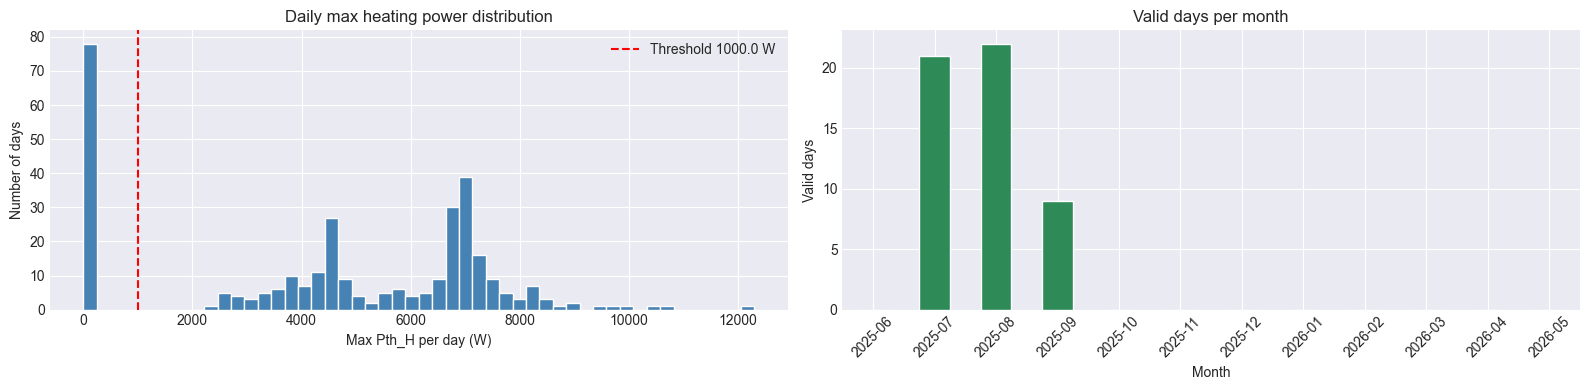


Rows after day filter: 14,976  (from 92,677)


In [9]:
# ── Plot: day validity overview ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Distribution of max Pth_H per day
axes[0].hist(day_stats["pth_h_max"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(PTH_H_MAX_W, color="red", linestyle="--", label=f"Threshold {PTH_H_MAX_W} W")
axes[0].set_xlabel("Max Pth_H per day (W)")
axes[0].set_ylabel("Number of days")
axes[0].set_title("Daily max heating power distribution")
axes[0].legend()

# Monthly valid-day counts
day_stats["month"] = pd.to_datetime(day_stats["date"]).dt.to_period("M").astype(str)
monthly = day_stats.groupby("month")["valid"].sum()
monthly.plot(kind="bar", ax=axes[1], color="seagreen", edgecolor="white")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Valid days")
axes[1].set_title("Valid days per month")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

valid_dates = set(day_stats.loc[day_stats["valid"], "date"])
assert len(valid_dates) >= 10, (
    f"Only {len(valid_dates)} valid days — need >= 10. "
    "Check PV data completeness and the Pth_H threshold.")
df_valid = df[df["date"].isin(valid_dates)].copy()
print(f"\nRows after day filter: {len(df_valid):,}  (from {len(df):,})")

## 4. Feature Engineering

In [10]:
# ── Core derived features ─────────────────────────────────────────────────────
# NOTE: All features must be computable from inputs available in the HA add-on
# at prediction time.  "# ADDON: ..." shows the exact production key / formula.

df_feat = df_valid.copy()

# Distance to overheating threshold
# ADDON: indoor_temp - OVERHEAT_THRESHOLD_C
df_feat["indoor_margin"] = df_feat["indoor_temp"] - OVERHEAT_THRESHOLD_C

# 30-min indoor trend  (6 × 5-min steps)
# ADDON: indoor_temp - features["indoor_temp_lag_30m"]
df_feat["indoor_trend_30m"] = df_feat["indoor_temp"] - df_feat["indoor_temp"].shift(6)

# 1h indoor trend  (12 × 5-min steps)
# ADDON: features["indoor_temp_delta_60m"]
df_feat["indoor_trend_1h"] = df_feat["indoor_temp"] - df_feat["indoor_temp"].shift(12)

# Outdoor – indoor differential
# ADDON: features["temp_diff_indoor_outdoor"]
df_feat["at_delta_indoor"] = df_feat["AT"] - df_feat["indoor_temp"]

# PV rolling means  (1h and 2h)
# ADDON: derived from features["pv_power_history"] rolling windows
df_feat["pv_roll_1h"] = df_feat["PV_Generate"].rolling(12, min_periods=6).mean()
df_feat["pv_roll_2h"] = df_feat["PV_Generate"].rolling(24, min_periods=12).mean()

# ── HP thermal state features ─────────────────────────────────────────────────
# Pth_PC sign: NEGATIVE when passive cooling is active (heat removed from house).
# ADDON: features["thermal_power_kw"] = (Vol_L_min/60) * c_p * (VLT - RLT)
#         — same sign convention: negative during passive cooling because RLT > VLT.
if "Pth_PC" in df_feat.columns:
    df_feat["thermal_power_kw"] = df_feat["Pth_PC"] / 1000.0
else:
    df_feat["thermal_power_kw"] = 0.0
    print("  ⚠ Pth_PC not found — thermal_power_kw set to 0")

# Supply – return temperature delta.  Negative during passive cooling (RLT > VLT).
# ADDON: features["delta_t"] = outlet_temp - inlet_temp
if "VLT" in df_feat.columns and "RLT" in df_feat.columns:
    df_feat["delta_t"] = df_feat["VLT"] - df_feat["RLT"]
else:
    df_feat["delta_t"] = 0.0
    print("  ⚠ VLT/RLT not found — delta_t set to 0")

# Driving force: floor-loop supply temperature vs room temperature.
# ADDON: features["outlet_indoor_diff"] = outlet_temp - indoor_temp
if "VLT" in df_feat.columns:
    df_feat["outlet_indoor_diff"] = df_feat["VLT"] - df_feat["indoor_temp"]
else:
    df_feat["outlet_indoor_diff"] = 0.0

# Cyclical time-of-day encoding
# ADDON: computed from current timestamp each cycle
hour_frac = df_feat.index.hour + df_feat.index.minute / 60.0
df_feat["hour_sin"] = np.sin(2 * np.pi * hour_frac / 24)
df_feat["hour_cos"] = np.cos(2 * np.pi * hour_frac / 24)

# Cyclical day-of-year encoding
doy = df_feat.index.dayofyear
df_feat["doy_sin"] = np.sin(2 * np.pi * doy / 365)
df_feat["doy_cos"] = np.cos(2 * np.pi * doy / 365)

print("Feature engineering done")


Feature engineering done


In [11]:
# ── Outdoor forecast columns  (AT_roh_1h … AT_roh_8h) ────────────────────────
# ADDON: features["temp_forecast_Nh"] from live weather API — no ffill needed in production.
# Only include columns that have actual data in the valid training period.
# (Some columns may be all-NaN if the weather API feature was added after the training window.)
forecast_cols_at = [
    f"AT_roh_{h}h" for h in range(1, 9)
    if f"AT_roh_{h}h" in df_feat.columns
    and df_feat[f"AT_roh_{h}h"].notna().mean() > 0.05
]
print(f"Outdoor forecast columns found: {forecast_cols_at}")
if not forecast_cols_at:
    print("  ⚠ No forecast columns have enough data in the training window — they will be excluded.")

# ── Feature list — only inputs available in the HA add-on ────────────────────
# Removed: Helligkeit    — no brightness sensor entity in add-on config
# Removed: Kuehlung_Soll — config constant (23.1 °C), not a live sensor reading
# Removed: Pth_H         — heating power ≈ 0 W on valid summer cooling days (zero signal)
FEATURE_COLS = (
    # ── Indoor state ─────────────────────────────────────────────────────────
    ["indoor_temp",           # ADDON: computed from sensor.rt_mittelwert
     "indoor_margin",         # ADDON: indoor_temp - OVERHEAT_THRESHOLD_C
     "indoor_trend_30m",      # ADDON: indoor_temp - features["indoor_temp_lag_30m"]
     "indoor_trend_1h"]       # ADDON: features["indoor_temp_delta_60m"]
    # ── Outdoor ──────────────────────────────────────────────────────────────
    + ["AT",                  # ADDON: features["outdoor_temp"]
       "at_delta_indoor"]     # ADDON: features["temp_diff_indoor_outdoor"]
    # ── Outdoor temperature forecasts (only those with data in training window)
    + forecast_cols_at        # ADDON: features["temp_forecast_Nh"]
    # ── Solar / PV ───────────────────────────────────────────────────────────
    + ["PV_Generate",         # ADDON: features["pv_now"]
       "pv_roll_1h",          # ADDON: rolling mean of pv_power_history (1 h)
       "pv_roll_2h"]          # ADDON: rolling mean of pv_power_history (2 h)
    # ── HP thermal state ─────────────────────────────────────────────────────
    + (["thermal_power_kw"]   if "thermal_power_kw"   in df_feat.columns else [])
                              # ADDON: features["thermal_power_kw"] = (Vol/60)*c_p*(VLT-RLT)
    + (["delta_t"]            if "delta_t"            in df_feat.columns else [])
                              # ADDON: features["delta_t"] = VLT - RLT
    + (["outlet_indoor_diff"] if "outlet_indoor_diff" in df_feat.columns else [])
                              # ADDON: features["outlet_indoor_diff"] = VLT - indoor_temp
    + (["VLT"]                if "VLT"                in df_feat.columns else [])
                              # ADDON: features["outlet_temp"]
    + (["RLT"]                if "RLT"                in df_feat.columns else [])
                              # ADDON: features["inlet_temp"]
    # ── Cyclical time ────────────────────────────────────────────────────────
    + ["hour_sin", "hour_cos",   # ADDON: computed from current timestamp
       "doy_sin",  "doy_cos"]    # ADDON: computed from current timestamp
)

print(f"\nTotal features: {len(FEATURE_COLS)}")
for f in FEATURE_COLS:
    print(f"  {f}")


Outdoor forecast columns found: ['AT_roh_4h']

Total features: 19
  indoor_temp
  indoor_margin
  indoor_trend_30m
  indoor_trend_1h
  AT
  at_delta_indoor
  AT_roh_4h
  PV_Generate
  pv_roll_1h
  pv_roll_2h
  thermal_power_kw
  delta_t
  outlet_indoor_diff
  VLT
  RLT
  hour_sin
  hour_cos
  doy_sin
  doy_cos


## 5. Label Creation

In [12]:
def make_label(series: pd.Series, horizon_steps: int, threshold: float) -> pd.Series:
    """Return 1 if max(series[t : t+horizon_steps]) > threshold.

    Reverse-rolling trick: reversing turns pandas look-back into
    look-forward. Tail rows (< horizon_steps) become NaN.
    """
    return (
        series[::-1]
        .rolling(horizon_steps, min_periods=horizon_steps)
        .max()[::-1] > threshold
    ).astype("Int8")  # nullable Int8: 0/1 with NaN for tail rows


df_feat["label_8h"]  = make_label(df_feat["indoor_temp"], LABEL_HORIZON_STEPS, OVERHEAT_THRESHOLD_C)
for h in EXTRA_HORIZONS_H:
    df_feat[f"label_{h}h"] = make_label(df_feat["indoor_temp"], h * STEPS_PER_HOUR, OVERHEAT_THRESHOLD_C)

# Drop rows where the 8h label cannot be computed (end of each contiguous day block).
# notna() is correct even when df_valid has day-boundary gaps;
# iloc[:-N] would under-trim in that case and leave NaN rows.
# TRAINING-ONLY: labels don't exist in production.
df_feat = df_feat[df_feat["label_8h"].notna()]

print("Label class balance:")
for col in ["label_8h"] + [f"label_{h}h" for h in EXTRA_HORIZONS_H]:
    n_pos = (df_feat[col] == 1).sum()
    n_tot = df_feat[col].notna().sum()
    print(f"  {col:12s}: {n_pos:5,} positive  /  {n_tot:6,} total  ({n_pos/n_tot*100:.1f}%)")


Label class balance:
  label_8h    : 7,084 positive  /  14,976 total  (47.3%)
  label_3h    : 5,274 positive  /  14,976 total  (35.2%)
  label_6h    : 6,396 positive  /  14,976 total  (42.7%)
  label_12h   : 8,181 positive  /  14,976 total  (54.6%)


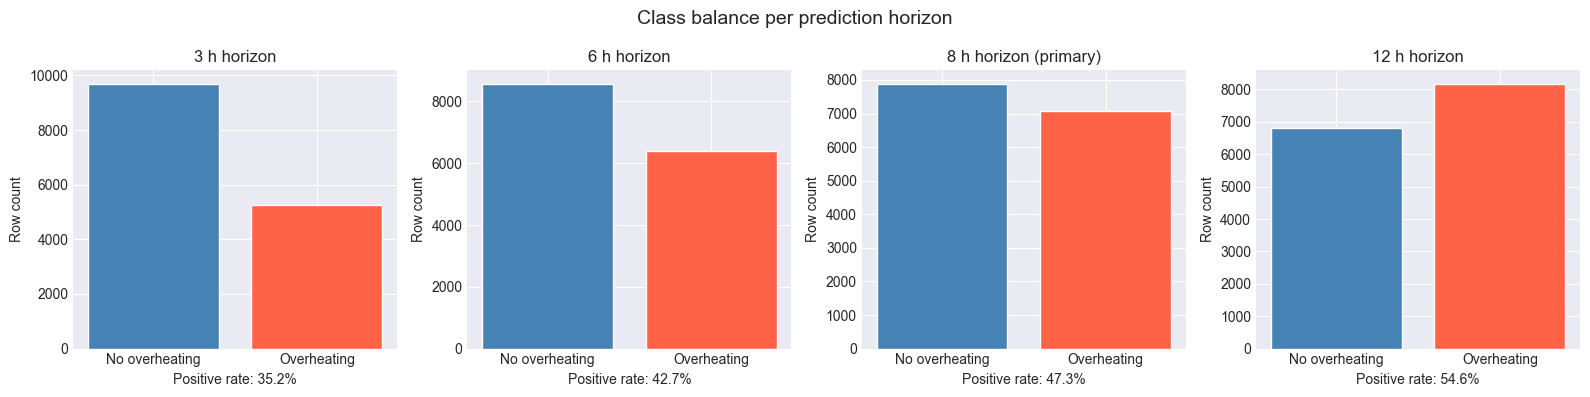

In [13]:
# ── Class balance plot ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
label_cols = ["label_3h", "label_6h", "label_8h", "label_12h"]
horizon_titles = ["3 h horizon", "6 h horizon", "8 h horizon (primary)", "12 h horizon"]

for ax, col, title in zip(axes, label_cols, horizon_titles):
    counts = df_feat[col].value_counts().sort_index()
    ax.bar(["No overheating", "Overheating"], [counts.get(0, 0), counts.get(1, 0)],
           color=["steelblue", "tomato"], edgecolor="white")
    ax.set_title(title)
    ax.set_ylabel("Row count")
    total = counts.sum()
    pct = counts.get(1, 0) / total * 100 if total else 0
    ax.set_xlabel(f"Positive rate: {pct:.1f}%")

plt.suptitle("Class balance per prediction horizon", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Train / Test Split

In [14]:
# ── NaN diagnostic — which column is blocking rows? ───────────────────────────
nan_pct = df_feat[FEATURE_COLS + ["label_8h"]].isna().mean() * 100
problematic = nan_pct[nan_pct > 1.0].sort_values(ascending=False)
if len(problematic):
    print("Columns with > 1% NaN (will reduce model_df size):")
    print(problematic.round(1).to_string())
else:
    print("All feature + label columns have ≤ 1% NaN ✓")

# ── Keep only rows with all features and label available ──────────────────────
model_df = df_feat[FEATURE_COLS + ["label_8h"]].dropna()
assert len(model_df) >= 1000, (
    f"Only {len(model_df)} complete rows — too few to train. "
    "Check NaN diagnostic above; AT_roh_Nh columns usually need the ffill in Section 2.")
print(f"\nRows with complete features + label: {len(model_df):,}")

X = model_df[FEATURE_COLS].values
y = model_df["label_8h"].astype(int).values

# ── Time-ordered 75 / 25 split (no shuffle!) ─────────────────────────────────
split_idx = int(len(model_df) * TRAIN_FRACTION)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

train_start = model_df.index[0]
train_end   = model_df.index[split_idx - 1]
test_start  = model_df.index[split_idx]
test_end    = model_df.index[-1]

print(f"\nTraining  : {train_start.date()} → {train_end.date()}  ({len(X_train):,} rows)")
print(f"Test      : {test_start.date()} → {test_end.date()}  ({len(X_test):,} rows)")
print(f"Train pos : {y_train.mean()*100:.1f}%   |   Test pos: {y_test.mean()*100:.1f}%")


All feature + label columns have ≤ 1% NaN ✓

Rows with complete features + label: 14,862

Training  : 2025-07-08 → 2025-08-21  (11,146 rows)
Test      : 2025-08-21 → 2025-09-20  (3,716 rows)
Train pos : 44.6%   |   Test pos: 55.9%


## 7. Model Training

In [15]:
# ── 7a: RandomForest ──────────────────────────────────────────────────────────
print("Training RandomForest…")
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
rf_prob_test  = rf.predict_proba(X_test)[:, 1]
rf_auc        = roc_auc_score(y_test, rf_prob_test)
rf_ap         = average_precision_score(y_test, rf_prob_test)
print(f"  RandomForest — ROC-AUC: {rf_auc:.4f}   Avg Precision: {rf_ap:.4f}")

Training RandomForest…
  RandomForest — ROC-AUC: 0.8273   Avg Precision: 0.7856


In [16]:
# ── 7b: LightGBM or GradientBoosting ─────────────────────────────────────────
scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f"scale_pos_weight / class ratio: {scale_pos:.2f}")

if USE_LGBM:
    print("Training LightGBM…")
    lgbm_model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=20,
        scale_pos_weight=scale_pos,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    lgbm_model.fit(X_train, y_train)
    boost_name = "LightGBM"
else:
    print("Training GradientBoostingClassifier (sklearn fallback)…")
    # GBC has no class_weight param; use sample_weight
    gbc_sample_weights = np.where(y_train == 1, scale_pos, 1.0)
    lgbm_model = GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        random_state=42,
    )
    lgbm_model.fit(X_train, y_train, sample_weight=gbc_sample_weights)
    boost_name = "GradientBoosting"

lgbm_prob_test = lgbm_model.predict_proba(X_test)[:, 1]
lgbm_auc       = roc_auc_score(y_test, lgbm_prob_test)
lgbm_ap        = average_precision_score(y_test, lgbm_prob_test)
print(f"  {boost_name} — ROC-AUC: {lgbm_auc:.4f}   Avg Precision: {lgbm_ap:.4f}")

scale_pos_weight / class ratio: 1.24
Training LightGBM…
  LightGBM — ROC-AUC: 0.8361   Avg Precision: 0.7965


c:\Users\Julia\Documents\Johannes\Pi 4\GitHub\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 8. Evaluation

In [17]:
# ── Naive baseline: AT > 22 °C AND PV_Generate > 500 W ───────────────────────
test_at  = model_df.iloc[split_idx:]["AT"].values
test_pv  = model_df.iloc[split_idx:]["PV_Generate"].values
baseline_pred = ((test_at > 22) & (test_pv > 500)).astype(float)

# Avoid division by zero if baseline never predicts positive
if baseline_pred.sum() > 0:
    baseline_auc = roc_auc_score(y_test, baseline_pred)
    baseline_ap  = average_precision_score(y_test, baseline_pred)
    print(f"Naive baseline  — ROC-AUC: {baseline_auc:.4f}   Avg Precision: {baseline_ap:.4f}")
else:
    print("Naive baseline never positive — AUC undefined")
    baseline_auc, baseline_ap = 0.5, 0.0

print(f"RandomForest    — ROC-AUC: {rf_auc:.4f}   Avg Precision: {rf_ap:.4f}")
print(f"{boost_name:16s}— ROC-AUC: {lgbm_auc:.4f}   Avg Precision: {lgbm_ap:.4f}")

Naive baseline  — ROC-AUC: 0.5700   Avg Precision: 0.6100
RandomForest    — ROC-AUC: 0.8273   Avg Precision: 0.7856
LightGBM        — ROC-AUC: 0.8361   Avg Precision: 0.7965


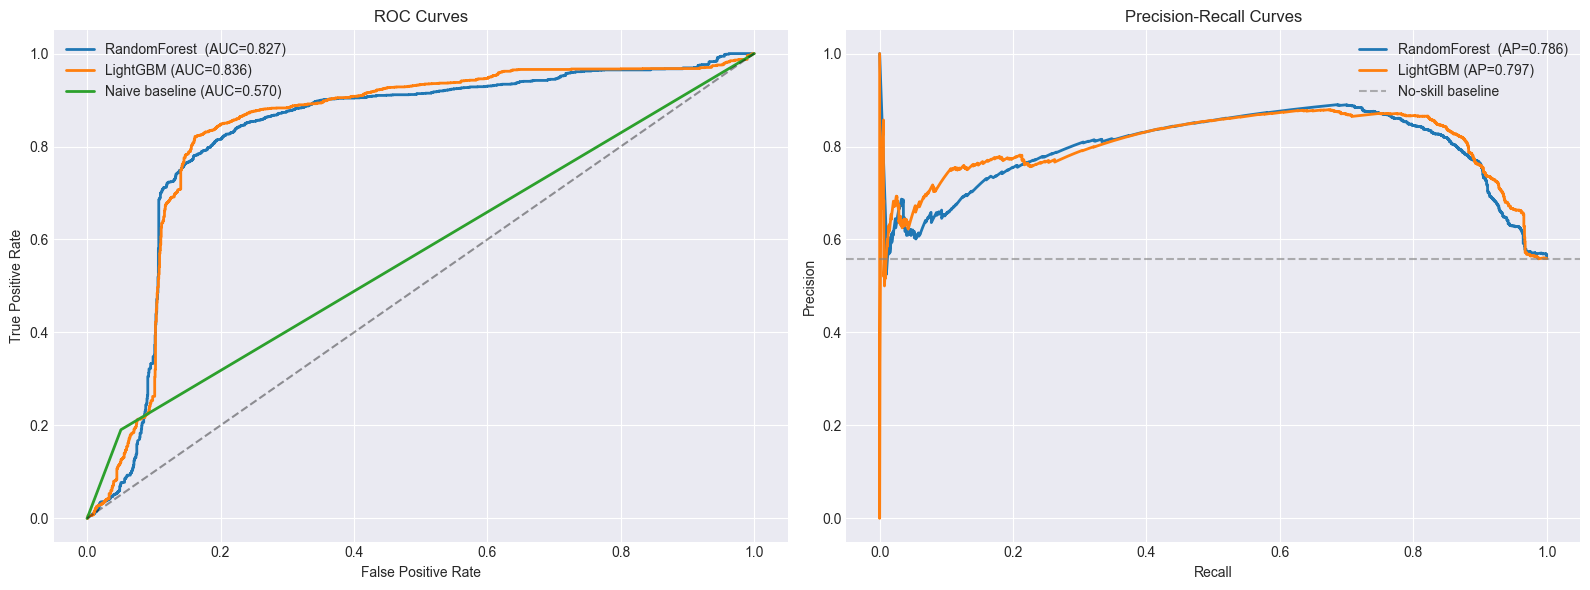

In [18]:
# ── ROC curves ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for prob, label, color in [
    (rf_prob_test,   f"RandomForest  (AUC={rf_auc:.3f})",   "steelblue"),
    (lgbm_prob_test, f"{boost_name} (AUC={lgbm_auc:.3f})", "seagreen"),
    (baseline_pred,  f"Naive baseline (AUC={baseline_auc:.3f})", "tomato"),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, label=label, linewidth=2)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend()

# ── Precision-Recall curves ───────────────────────────────────────────────────
for prob, label, color in [
    (rf_prob_test,   f"RandomForest  (AP={rf_ap:.3f})",   "steelblue"),
    (lgbm_prob_test, f"{boost_name} (AP={lgbm_ap:.3f})", "seagreen"),
]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    axes[1].plot(rec, prec, label=label, linewidth=2)

axes[1].axhline(y_test.mean(), linestyle="--", color="grey", alpha=0.6, label="No-skill baseline")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves")
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
# ── Operating point selection: recall >= 0.80 ─────────────────────────────────
def select_threshold(y_true, prob, min_recall=0.80):
    """Return threshold that maximises precision subject to recall >= min_recall."""
    prec, rec, thresholds = precision_recall_curve(y_true, prob)
    # precision_recall_curve adds an extra point at the end; align lengths
    prec, rec = prec[:-1], rec[:-1]
    mask = rec >= min_recall
    if not mask.any():
        return float(thresholds[np.argmax(rec)])
    best_idx = np.argmax(prec[mask])
    return float(thresholds[mask][best_idx])

rf_threshold   = select_threshold(y_test, rf_prob_test)
lgbm_threshold = select_threshold(y_test, lgbm_prob_test)

rf_pred_bin   = (rf_prob_test   >= rf_threshold).astype(int)
lgbm_pred_bin = (lgbm_prob_test >= lgbm_threshold).astype(int)

print(f"Chosen threshold — RF: {rf_threshold:.3f}   {boost_name}: {lgbm_threshold:.3f}")
print("\n── RandomForest classification report ──")
print(classification_report(y_test, rf_pred_bin, target_names=["No overheating", "Overheating"]))
print(f"\n── {boost_name} classification report ──")
print(classification_report(y_test, lgbm_pred_bin, target_names=["No overheating", "Overheating"]))

Chosen threshold — RF: 0.414   LightGBM: 0.004

── RandomForest classification report ──
                precision    recall  f1-score   support

No overheating       0.76      0.81      0.79      1639
   Overheating       0.85      0.80      0.82      2077

      accuracy                           0.81      3716
     macro avg       0.80      0.81      0.81      3716
  weighted avg       0.81      0.81      0.81      3716


── LightGBM classification report ──
                precision    recall  f1-score   support

No overheating       0.77      0.84      0.81      1639
   Overheating       0.87      0.80      0.83      2077

      accuracy                           0.82      3716
     macro avg       0.82      0.82      0.82      3716
  weighted avg       0.82      0.82      0.82      3716



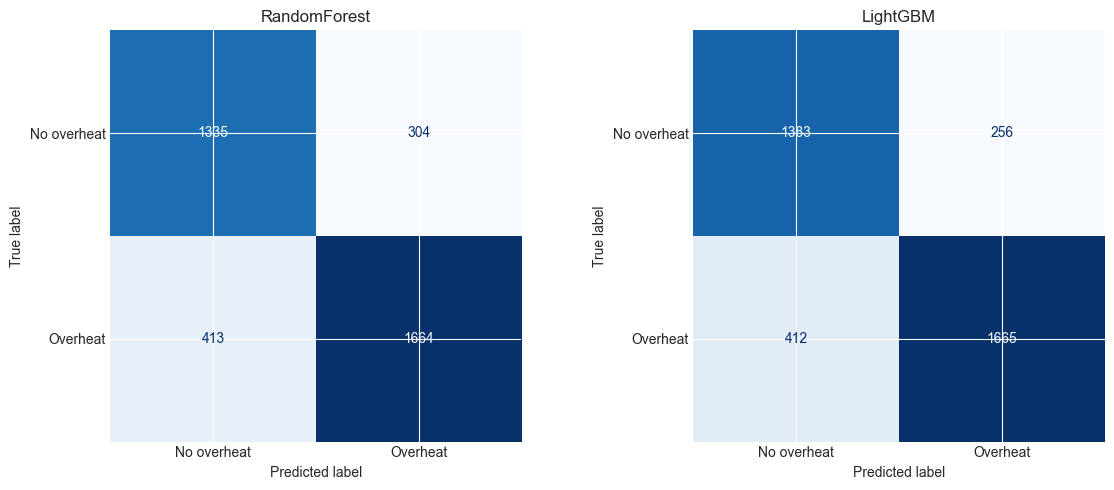

In [20]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, title in [
    (axes[0], rf_pred_bin,   "RandomForest"),
    (axes[1], lgbm_pred_bin, boost_name),
]:
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No overheat", "Overheat"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)
plt.tight_layout()
plt.show()

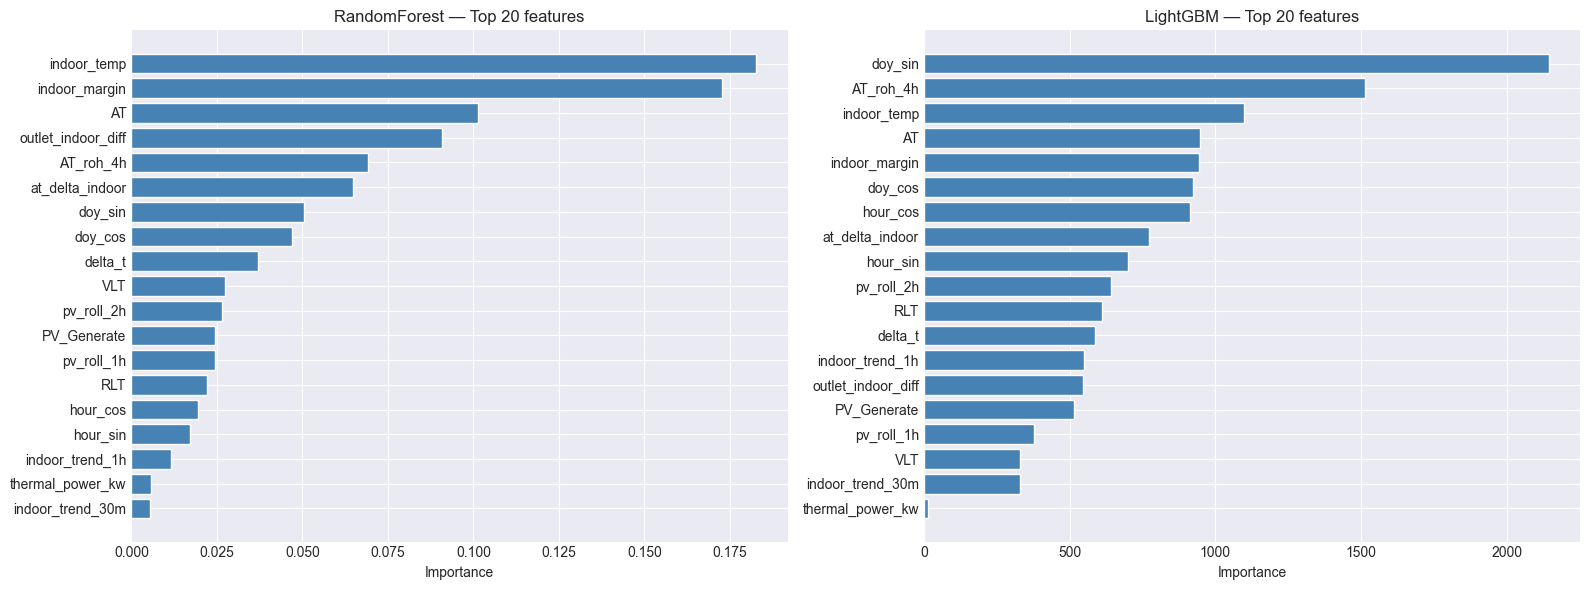

In [21]:
# ── Feature importance ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, title in [
    (axes[0], rf,         "RandomForest"),
    (axes[1], lgbm_model, boost_name),
]:
    importances = model.feature_importances_
    sorted_idx  = np.argsort(importances)[::-1][:20]  # top 20
    ax.barh(
        [FEATURE_COLS[i] for i in sorted_idx][::-1],
        importances[sorted_idx][::-1],
        color="steelblue",
        edgecolor="white",
    )
    ax.set_xlabel("Importance")
    ax.set_title(f"{title} — Top 20 features")

plt.tight_layout()
plt.show()

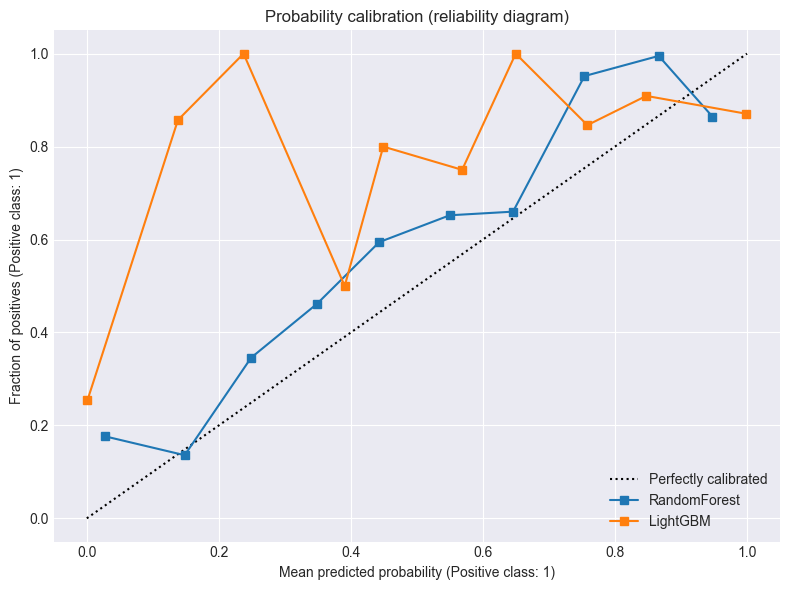

In [22]:
# ── Calibration curves ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for prob, label, color in [
    (rf_prob_test,   "RandomForest", "steelblue"),
    (lgbm_prob_test, boost_name,     "seagreen"),
]:
    CalibrationDisplay.from_predictions(
        y_test, prob, n_bins=10, ax=ax, name=label
    )
ax.set_title("Probability calibration (reliability diagram)")
plt.tight_layout()
plt.show()

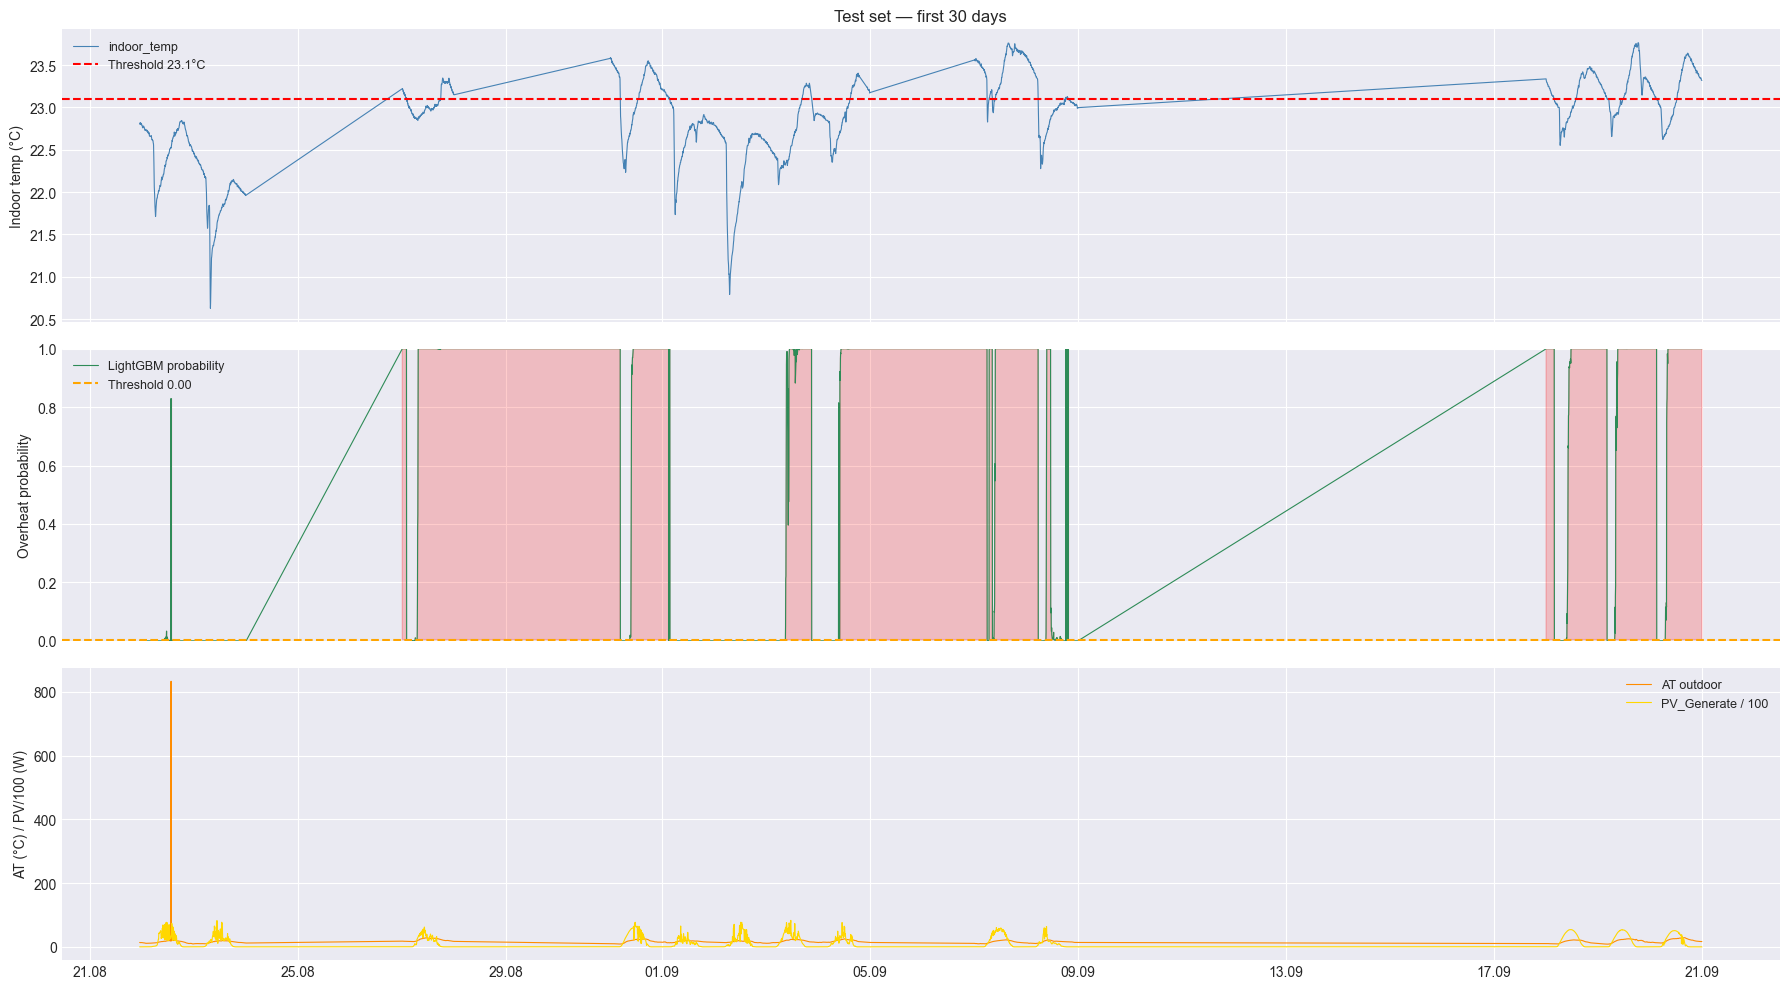

In [23]:
# ── Time-series view: predicted probability vs actual overheating on test set ─
test_index = model_df.index[split_idx:]

# Pick best model by ROC-AUC for the overlay plot
best_prob  = rf_prob_test if rf_auc >= lgbm_auc else lgbm_prob_test
best_name  = "RandomForest" if rf_auc >= lgbm_auc else boost_name
best_thr   = rf_threshold if rf_auc >= lgbm_auc else lgbm_threshold

# Limit plot to first 30 days of test set for clarity
n_plot = min(len(test_index), 30 * 24 * 12)

fig, axes = plt.subplots(3, 1, figsize=(18, 10), sharex=True)

axes[0].plot(test_index[:n_plot], model_df.iloc[split_idx:split_idx+n_plot]["indoor_temp"].values,
             color="steelblue", linewidth=0.8, label="indoor_temp")
axes[0].axhline(OVERHEAT_THRESHOLD_C, color="red", linestyle="--", label=f"Threshold {OVERHEAT_THRESHOLD_C}°C")
axes[0].set_ylabel("Indoor temp (°C)")
axes[0].legend(fontsize=9)
axes[0].set_title("Test set — first 30 days")

axes[1].plot(test_index[:n_plot], best_prob[:n_plot], color="seagreen", linewidth=0.8,
             label=f"{best_name} probability")
axes[1].axhline(best_thr, color="orange", linestyle="--", label=f"Threshold {best_thr:.2f}")
axes[1].fill_between(test_index[:n_plot], best_prob[:n_plot], best_thr,
                     where=best_prob[:n_plot] >= best_thr, alpha=0.2, color="red")
axes[1].set_ylabel("Overheat probability")
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=9)

axes[2].plot(test_index[:n_plot], model_df.iloc[split_idx:split_idx+n_plot]["AT"].values,
             color="darkorange", linewidth=0.8, label="AT outdoor")
axes[2].plot(test_index[:n_plot], model_df.iloc[split_idx:split_idx+n_plot]["PV_Generate"].values / 100,
             color="gold", linewidth=0.8, label="PV_Generate / 100")
axes[2].set_ylabel("AT (°C) / PV/100 (W)")
axes[2].legend(fontsize=9)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))

plt.tight_layout()
plt.show()

## 9. Model Export

In [24]:
# ── Save models ───────────────────────────────────────────────────────────────
rf_path   = os.path.join(MODELS_DIR, "overheating_predictor_rf.joblib")
lgbm_path = os.path.join(MODELS_DIR, "overheating_predictor_lgbm.joblib")

joblib.dump(rf,         rf_path)
joblib.dump(lgbm_model, lgbm_path)
print(f"Saved: {rf_path}")
print(f"Saved: {lgbm_path}")

# ── Save metadata ─────────────────────────────────────────────────────────────
best_model_name = "rf" if rf_auc >= lgbm_auc else "lgbm"

metadata = {
    "created_at"            : datetime.utcnow().isoformat() + "Z",
    "overheat_threshold_c"  : OVERHEAT_THRESHOLD_C,
    "label_horizon_h"       : LABEL_HORIZON_H,
    "train_date_range"      : [str(train_start.date()), str(train_end.date())],
    "test_date_range"       : [str(test_start.date()), str(test_end.date())],
    "feature_cols"          : FEATURE_COLS,
    "best_model"            : best_model_name,
    "rf": {
        "roc_auc"      : round(rf_auc, 5),
        "avg_precision": round(rf_ap, 5),
        "threshold"    : round(rf_threshold, 5),
        "path"         : rf_path,
    },
    "lgbm": {
        "model_type"   : boost_name,
        "roc_auc"      : round(lgbm_auc, 5),
        "avg_precision": round(lgbm_ap, 5),
        "threshold"    : round(lgbm_threshold, 5),
        "path"         : lgbm_path,
    },
    "feature_mapping_for_live_system": {
        # ── Indoor state ─────────────────────────────────────────────────────
        "indoor_temp"        : "computed from sensor.rt_mittelwert (median of room sensors)",
        "indoor_margin"      : "indoor_temp - OVERHEAT_THRESHOLD_C",
        "indoor_trend_30m"   : "indoor_temp - features['indoor_temp_lag_30m']",
        "indoor_trend_1h"    : "features['indoor_temp_delta_60m']",
        # ── Outdoor ──────────────────────────────────────────────────────────
        "AT"                 : "features['outdoor_temp']",
        "at_delta_indoor"    : "features['temp_diff_indoor_outdoor']",
        # ── Outdoor forecast (only columns with > 5% non-NaN in training data)
        "AT_roh_4h"          : "features['temp_forecast_4h']  (hourly weather API)",
        # ── Solar / PV ───────────────────────────────────────────────────────
        "PV_Generate"        : "features['pv_now']",
        "pv_roll_1h"         : "rolling mean of pv_power_history over last 1 h",
        "pv_roll_2h"         : "rolling mean of pv_power_history over last 2 h",
        # ── HP thermal state ─────────────────────────────────────────────────
        "thermal_power_kw"   : "features['thermal_power_kw']  = (Vol/60)*c_p*(VLT-RLT)/1000; "
                               "NEGATIVE when cooling, ~0 when idle",
        "delta_t"            : "features['delta_t']  = VLT - RLT; "
                               "negative during passive cooling (RLT > VLT)",
        "outlet_indoor_diff" : "features['outlet_indoor_diff']  = VLT - indoor_temp",
        "VLT"                : "features['outlet_temp']  (Vorlauftemperatur / supply)",
        "RLT"                : "features['inlet_temp']   (Rücklauftemperatur / return)",
        # ── Cyclical time ────────────────────────────────────────────────────
        "hour_sin"           : "sin(2*pi*hour/24)  — computed from current timestamp",
        "hour_cos"           : "cos(2*pi*hour/24)",
        "doy_sin"            : "sin(2*pi*doy/365)  — computed from current timestamp",
        "doy_cos"            : "cos(2*pi*doy/365)",
    },
}

meta_path = os.path.join(MODELS_DIR, "model_metadata.json")
with open(meta_path, "w") as fh:
    json.dump(metadata, fh, indent=2)
print(f"Saved: {meta_path}")

print("\n── Model Card ──────────────────────────────────────────────")
print(f"  Overheat threshold : {OVERHEAT_THRESHOLD_C} °C")
print(f"  Prediction horizon : {LABEL_HORIZON_H} h")
print(f"  Training rows      : {len(X_train):,}")
print(f"  Test rows          : {len(X_test):,}")
print(f"  RandomForest       : ROC-AUC={rf_auc:.4f}  threshold={rf_threshold:.3f}")
print(f"  {boost_name:16s}: ROC-AUC={lgbm_auc:.4f}  threshold={lgbm_threshold:.3f}")
print(f"  Best model         : {best_model_name.upper()}")
print(f"  Features ({len(FEATURE_COLS)})      : {', '.join(FEATURE_COLS)}")


Saved: c:\Users\Julia\Documents\Johannes\Pi 4\GitHub\ml_heating_underfloor-main\notebooks\analysis\models\overheating_predictor_rf.joblib
Saved: c:\Users\Julia\Documents\Johannes\Pi 4\GitHub\ml_heating_underfloor-main\notebooks\analysis\models\overheating_predictor_lgbm.joblib
Saved: c:\Users\Julia\Documents\Johannes\Pi 4\GitHub\ml_heating_underfloor-main\notebooks\analysis\models\model_metadata.json

── Model Card ──────────────────────────────────────────────
  Overheat threshold : 23.1 °C
  Prediction horizon : 8 h
  Training rows      : 11,146
  Test rows          : 3,716
  RandomForest       : ROC-AUC=0.8273  threshold=0.414
  LightGBM        : ROC-AUC=0.8361  threshold=0.004
  Best model         : LGBM
  Features (19)      : indoor_temp, indoor_margin, indoor_trend_30m, indoor_trend_1h, AT, at_delta_indoor, AT_roh_4h, PV_Generate, pv_roll_1h, pv_roll_2h, thermal_power_kw, delta_t, outlet_indoor_diff, VLT, RLT, hour_sin, hour_cos, doy_sin, doy_cos


## 10. Cross-Validation (optional)

Time-series walk-forward CV to verify that test AUC is stable across folds.
This cell may take several minutes on large datasets.

In [25]:
tscv = TimeSeriesSplit(n_splits=5)
rf_cv_aucs   = []
lgbm_cv_aucs = []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
    rf_fold = RandomForestClassifier(
        n_estimators=100, max_depth=10, class_weight="balanced",
        random_state=42, n_jobs=-1)
    rf_fold.fit(X[tr_idx], y[tr_idx])
    rf_cv_aucs.append(roc_auc_score(y[val_idx], rf_fold.predict_proba(X[val_idx])[:, 1]))

    if USE_LGBM:
        boost_fold = lgb.LGBMClassifier(
            n_estimators=200, learning_rate=0.05, num_leaves=31,
            scale_pos_weight=scale_pos, random_state=42, n_jobs=-1, verbose=-1)
        # LightGBM: scale_pos_weight in the constructor already handles class imbalance.
        # Do NOT also pass sample_weight — that would double-count it.
        boost_fold.fit(X[tr_idx], y[tr_idx])
    else:
        boost_fold = GradientBoostingClassifier(
            n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
        # GBC has no scale_pos_weight, so sample_weight is the correct mechanism.
        fold_sw = np.where(y[tr_idx] == 1, scale_pos, 1.0)
        boost_fold.fit(X[tr_idx], y[tr_idx], sample_weight=fold_sw)

    lgbm_cv_aucs.append(roc_auc_score(y[val_idx], boost_fold.predict_proba(X[val_idx])[:, 1]))
    print(f"  Fold {fold+1}: RF={rf_cv_aucs[-1]:.4f}  {boost_name}={lgbm_cv_aucs[-1]:.4f}")

print(f"\nCV mean  RF={np.mean(rf_cv_aucs):.4f} ± {np.std(rf_cv_aucs):.4f}")
print(f"CV mean  {boost_name}={np.mean(lgbm_cv_aucs):.4f} ± {np.std(lgbm_cv_aucs):.4f}")


c:\Users\Julia\Documents\Johannes\Pi 4\GitHub\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 1: RF=0.9057  LightGBM=0.8965


c:\Users\Julia\Documents\Johannes\Pi 4\GitHub\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 2: RF=0.8641  LightGBM=0.8253


c:\Users\Julia\Documents\Johannes\Pi 4\GitHub\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 3: RF=0.9441  LightGBM=0.9661


c:\Users\Julia\Documents\Johannes\Pi 4\GitHub\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 4: RF=0.9081  LightGBM=0.9023
  Fold 5: RF=0.8457  LightGBM=0.8083

CV mean  RF=0.8935 ± 0.0348
CV mean  LightGBM=0.8797 ± 0.0571


c:\Users\Julia\Documents\Johannes\Pi 4\GitHub\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
